In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import os
from matplotlib import rcParams

%matplotlib inline

rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

# RUN1848

In [3]:
import glob

csv_folder = "/scratch/elena/9Li/results/run1848"
csv_files = sorted(glob.glob(f"{csv_folder}/Li9_clusters_chunk_*.csv"))

print(f"Found {len(csv_files)} chunk files")

df_list = []
for f in csv_files:
    try:
        df_chunk = pd.read_csv(f)
        if not df_chunk.empty:   # filtrar CSV vacíos
            df_chunk['t_window_start_s'] = df_chunk['t_window_start_ns'] / 1e9            # absolute time [s]
            df_chunk['t_window_start_rel_ms'] = df_chunk['t_window_start_rel_ns'] / 1e6   # relative time [ms]

            df_chunk = df_chunk[['t_window_start_s', 't_window_start_rel_ms', 'nHits', 'spill_id']]

            df_list.append(df_chunk)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {f}")  #era hasta el 47 en el .sh 

# concatenate all chunks
df = pd.concat(df_list, ignore_index=True)


Found 48 chunk files


In [4]:
import glob
import pandas as pd

csv_folder = "/scratch/elena/9Li/results/run1848"
csv_files = sorted(glob.glob(f"{csv_folder}/Li9_clusters_chunk_*.csv"))

print(f"Found {len(csv_files)} chunk files")

df_list = []
for f in csv_files:
    try:
        df_chunk = pd.read_csv(f)
        if not df_chunk.empty:   # filter empty CSVs
            # Add new columns without dropping any existing ones
            df_chunk['t_window_start_s'] = df_chunk['t_window_start_ns'] / 1e9            # absolute time [s]
            df_chunk['t_window_start_rel_ms'] = df_chunk['t_window_start_rel_ns'] / 1e6   # relative time [ms]

            df_list.append(df_chunk)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {f}")

# concatenate all chunks
df = pd.concat(df_list, ignore_index=True)

print(f"Total clusters: {len(df)}")
display(df)

Found 48 chunk files
Total clusters: 661773


,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,t_window_start_s,t_window_start_rel_ms
0,1.600714e+10,8.212652e+04,39,0,"[34, 32, 26, 26, 26, 23, 16, 16, 83, 83, 17, 9...","[78, 75, 60, 60, 60, 47, 73, 73, 28, 28, 29, 1...","[0, 7, 6, 10, 12, 9, 4, 13, 14, 0, 6, 11, 0, 7...","[17, 2, 8, 10, 4, 3, 1, 12, 13, 17, 8, 11, 17,...","[16007140414.384735, 16007140411.615402, 16007...","[106.0, 149.0, 103.0, 140.0, 190.0, 82.0, 109....",16.007140,0.082127
1,1.600714e+10,8.597224e+04,25,0,"[16, 21, 21, 98, 47, 99, 99, 19, 1, 27, 11, 46...","[73, 64, 64, 100, 13, 90, 90, 41, 70, 2, 10, 4...","[3, 5, 15, 11, 16, 5, 8, 2, 7, 0, 8, 9, 2, 9, ...","[18, 7, 5, 11, 14, 7, 9, 0, 2, 17, 9, 3, 0, 3,...","[16007144267.85772, 16007144256.741348, 160071...","[97.0, 124.0, 74.0, 183.0, 137.0, 157.0, 219.0...",16.007144,0.085972
2,1.600717e+10,1.112982e+05,39,0,"[26, 80, 80, 73, 44, 107, 99, 1, 22, 22, 14, 4...","[60, 30, 30, 31, 43, 44, 90, 70, 82, 82, 53, 7...","[5, 18, 2, 4, 15, 0, 17, 3, 1, 17, 18, 0, 2, 2...","[7, 16, 0, 1, 5, 17, 15, 18, 6, 15, 16, 17, 0,...","[16007169593.366247, 16007169587.131247, 16007...","[57.0, 83.0, 260.0, 182.0, 154.0, 134.0, 405.0...",16.007170,0.111298
3,1.600717e+10,1.136287e+05,39,0,"[26, 23, 16, 15, 73, 47, 99, 1, 87, 8, 8, 11, ...","[60, 47, 73, 58, 31, 13, 90, 70, 88, 84, 84, 1...","[14, 14, 3, 15, 12, 13, 4, 4, 3, 3, 6, 3, 11, ...","[13, 13, 18, 5, 4, 12, 1, 1, 18, 18, 8, 18, 11...","[16007171916.884207, 16007171917.886374, 16007...","[125.0, 138.0, 101.0, 109.0, 143.0, 350.0, 136...",16.007172,0.113629
4,1.600719e+10,1.291772e+05,39,0,"[23, 16, 16, 16, 83, 103, 89, 111, 111, 111, 9...","[47, 73, 73, 73, 28, 98, 89, 97, 97, 97, 90, 9...","[3, 1, 17, 14, 11, 1, 18, 11, 7, 10, 2, 18, 1,...","[18, 6, 15, 13, 11, 6, 16, 11, 2, 10, 0, 16, 6...","[16007187464.494902, 16007187462.976036, 16007...","[169.0, 64.0, 63.0, 132.0, 122.0, 149.0, 186.0...",16.007187,0.129177
...,...,...,...,...,...,...,...,...,...,...,...,...
661768,2.176114e+12,4.965549e+08,39,55,"[17, 17, 83, 107, 44, 113, 97, 11, 115, 3, 92,...","[29, 29, 28, 44, 43, 26, 92, 10, 57, 68, 25, 4...","[9, 11, 14, 9, 14, 17, 3, 5, 12, 7, 15, 12, 3,...","[3, 11, 13, 3, 13, 15, 18, 7, 4, 2, 5, 4, 18, ...","[2176113716515.3147, 2176113716515.1145, 21761...","[379.0, 370.0, 148.0, 200.0, 151.0, 67.0, 222....",2176.113717,496.554853
661769,2.176114e+12,4.966079e+08,39,55,"[111, 103, 26, 99, 93, 16, 98, 23, 25, 17, 83,...","[97, 98, 60, 90, 101, 73, 100, 47, 62, 29, 28,...","[11, 5, 1, 4, 12, 4, 8, 7, 1, 0, 15, 3, 6, 16,...","[11, 7, 6, 1, 4, 1, 9, 2, 6, 17, 5, 18, 8, 14,...","[2176113769593.614, 2176113769600.4482, 217611...","[132.0, 151.0, 214.0, 134.0, 162.0, 140.0, 76....",2176.113770,496.607930
661770,2.176116e+12,4.984136e+08,39,55,"[99, 93, 98, 98, 23, 20, 83, 107, 8, 11, 11, 1...","[90, 101, 100, 100, 47, 81, 28, 44, 84, 10, 10...","[12, 18, 17, 9, 2, 5, 16, 2, 6, 5, 6, 9, 10, 8...","[4, 16, 15, 3, 0, 7, 14, 0, 8, 7, 8, 3, 10, 9,...","[2176115575277.3162, 2176115575273.8496, 21761...","[188.0, 163.0, 166.0, 85.0, 119.0, 135.0, 81.0...",2176.115575,498.413599
661771,2.176116e+12,4.987489e+08,39,55,"[111, 99, 93, 89, 80, 113, 87, 27, 11, 11, 115...","[97, 90, 101, 89, 30, 26, 88, 2, 10, 10, 57, 7...","[15, 9, 12, 18, 16, 4, 8, 3, 3, 4, 3, 16, 14, ...","[5, 3, 4, 16, 14, 1, 9, 18, 18, 1, 18, 14, 13,...","[2176115910538.2803, 2176115910550.391, 217611...","[165.0, 155.0, 255.0, 112.0, 131.0, 105.0, 85....",2176.115911,498.748865


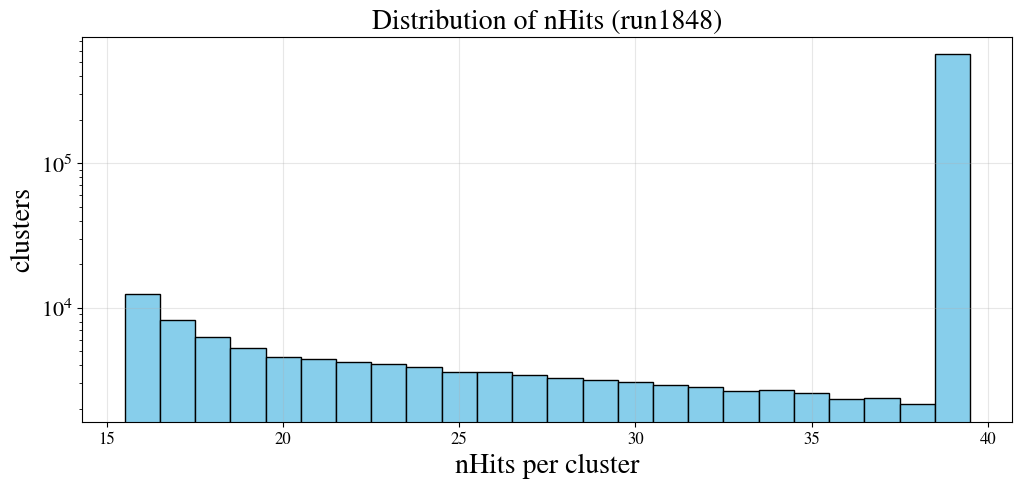

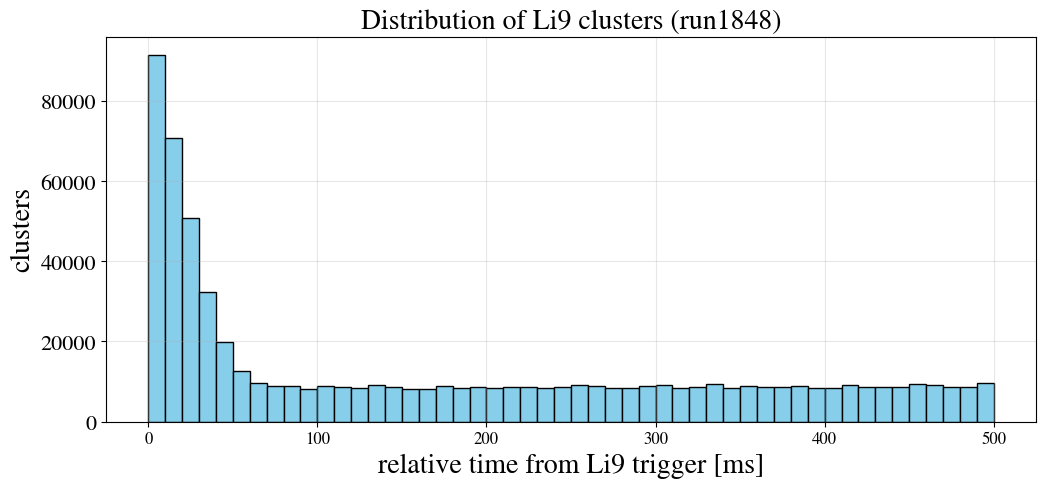

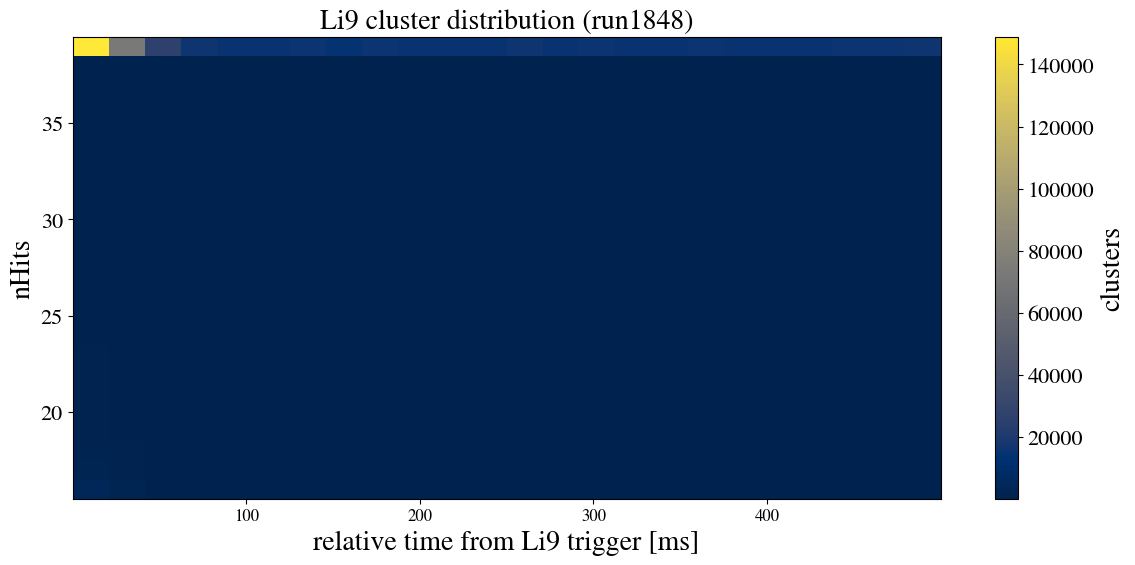

In [5]:
# -------------------------
# 2. 1D Histograms
# -------------------------

# Histogram: nHits per cluster
plt.figure(figsize=(12,5))
n_bins = np.arange(df['nHits'].min(), df['nHits'].max()+2) - 0.5            # +2 ensures the top-most value lands in a bin, the -0.5 centers bins on integers.
plt.hist(df['nHits'], bins=n_bins, color='skyblue', edgecolor='black')      #that's why we were missing the peak @ 40 before (only +1)
plt.yscale("log")
plt.xlabel("nHits per cluster")
plt.ylabel("clusters")
plt.title("Distribution of nHits (run1848)")
plt.grid(True, alpha=0.3)
plt.show()

# Histogram: relative time from Li9 window start
plt.figure(figsize=(12,5))
plt.hist(df['t_window_start_rel_ms'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("relative time from Li9 trigger [ms]")
plt.ylabel("clusters")
plt.title("Distribution of Li9 clusters (run1848)")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# 3. 2D Histogram / Heatmap
# -------------------------

x = df['t_window_start_rel_ms']
y = df['nHits']

# Binning
x_bins = np.linspace(x.min(), x.max(), 25)       # finer bins for time
y_bins = np.arange(y.min()-0.5, y.max()+1.5, 1)  # integer nHits bins

H, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

plt.figure(figsize=(14,6))
plt.pcolormesh(xedges, yedges, H.T, cmap='cividis', shading='auto')
plt.colorbar(label='clusters')
plt.xlabel('relative time from Li9 trigger [ms]')
plt.ylabel('nHits')
plt.title('Li9 cluster distribution (run1848)')
plt.show()